In [24]:
import numpy as np
import matplotlib.pyplot as plt
import time

import jax
import jax.numpy as jnp

import importlib, os
import east
importlib.reload(east)

plt.rcParams['figure.dpi'] = 120


## Preliminary pooled DMD smoke test

This notebook starts with the fastest isoconfigurational regime from `Isoconfigurational.ipynb` (`l=3`) and asks a narrow first question: can exact DMD reproduce walker-averaged single-site propensity decay?

For this first pass the dictionary is just `{1, s_i}` with equilibrium centering/scaling on the spin observables. Product clusters can be added after this baseline is working. The important upgrade here is that DMD is fit from snapshot pairs pooled across several independent starting configurations.


In [25]:
key = jax.random.PRNGKey(11)

# Use a high-temperature case from Isoconfigurational.ipynb so this is quick.
l_test = 3
T = float(east.temperature_from_length(l_test))
c_eq = float(east.concentration(T))

# Small smoke-test values. Increase n_configs / n_walkers once the pipeline looks right.
N = 256
n_configs = 16
n_walkers = 128
n_records = 500

# Reuse the ACF-derived window when present; otherwise use a conservative fast fallback.
tau_acf_ref = None
if os.path.exists('acf_results.npy'):
    acf_results = np.load('acf_results.npy', allow_pickle=True).item()
    if l_test in acf_results:
        tau_acf_ref = float(acf_results[l_test]['tau'])
        dt_record = tau_acf_ref / 250
    else:
        dt_record = 0.25
else:
    dt_record = 0.25

times = np.arange(n_records + 1) * dt_record
print(f'l={l_test}, T={T:.4f}, c_eq={c_eq:.4f}')
print(f'N={N}, configs={n_configs}, walkers/config={n_walkers}')
if tau_acf_ref is None:
    print(f'dt={dt_record:.4g}, max_t={times[-1]:.2f}')
else:
    print(f'dt={dt_record:.4g}, max_t={times[-1]:.2f} ({times[-1] / tau_acf_ref:.2f} tau_acf)')


l=3, T=1.4427, c_eq=0.3333
N=256, configs=16, walkers/config=128
dt=0.04279, max_t=21.40 (2.00 tau_acf)


In [26]:
def sample_fixed_concentration_config(key, N, c_eq):
    """Equilibrium-like initial state with exactly round(N c_eq) excitations."""
    n_up = int(round(N * c_eq))
    return jax.random.permutation(
        key,
        jnp.concatenate([
            jnp.ones(n_up, dtype=jnp.int32),
            jnp.zeros(N - n_up, dtype=jnp.int32),
        ])
    )

mean_trajs = []
state_inits = []

t0 = time.time()
for config_idx in range(n_configs):
    key, init_key, run_key = jax.random.split(key, 3)
    state_init = sample_fixed_concentration_config(init_key, N, c_eq)
    mean_traj, walker_trajs = east.isoconfigurational_ensemble(
        N, T, dt_record, n_records, n_walkers, state_init, run_key
    )
    mean_trajs.append(np.asarray(mean_traj))
    state_inits.append(np.asarray(state_init))
    del walker_trajs
    print(f'config {config_idx + 1:2d}/{n_configs}: mean_traj {tuple(mean_traj.shape)}')

mean_trajs = np.stack(mean_trajs, axis=0)      # (n_configs, time, N)
state_inits = np.stack(state_inits, axis=0)    # (n_configs, N)
print(f'generated mean_trajs {mean_trajs.shape} in {time.time() - t0:.1f}s')


config  1/16: mean_traj (501, 256)
config  2/16: mean_traj (501, 256)
config  3/16: mean_traj (501, 256)
config  4/16: mean_traj (501, 256)
config  5/16: mean_traj (501, 256)
config  6/16: mean_traj (501, 256)
config  7/16: mean_traj (501, 256)
config  8/16: mean_traj (501, 256)
config  9/16: mean_traj (501, 256)
config 10/16: mean_traj (501, 256)
config 11/16: mean_traj (501, 256)
config 12/16: mean_traj (501, 256)
config 13/16: mean_traj (501, 256)
config 14/16: mean_traj (501, 256)
config 15/16: mean_traj (501, 256)
config 16/16: mean_traj (501, 256)
generated mean_trajs (16, 501, 256) in 22.9s


## Single-site dictionary

The DMD state is `[1, standardized s_0, ..., standardized s_{N-1}]`. The constant observable is left uncentered so the affine equilibrium shift is represented explicitly; the spin coordinates are standardized by the exact Bernoulli equilibrium statistics.


In [27]:
def single_site_dictionary(mean_spins, c_eq):
    """Return standardized [1, s_i] features from walker-averaged spins."""
    mean_spins = np.asarray(mean_spins, dtype=np.float64)
    sigma = np.sqrt(c_eq * (1.0 - c_eq))
    spin_features = (mean_spins - c_eq) / sigma
    const = np.ones((mean_spins.shape[0], 1), dtype=np.float64)
    return np.hstack([const, spin_features])

Psis = np.stack([
    single_site_dictionary(mean_trajs[j], c_eq)
    for j in range(n_configs)
], axis=0)                                      # (n_configs, time, D)

X = np.concatenate([Psis[j, :-1].T for j in range(n_configs)], axis=1)
Y = np.concatenate([Psis[j, 1:].T for j in range(n_configs)], axis=1)
D, M = X.shape
print(f'Psis={Psis.shape}, D={D}, pooled snapshot pairs={M}')


Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000


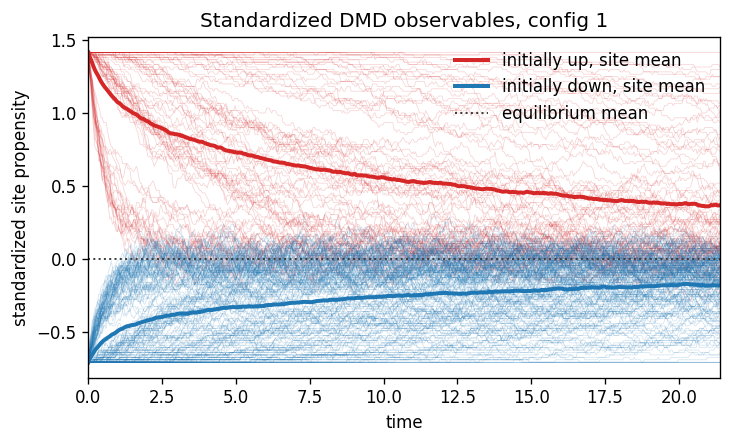

In [28]:
plot_config = 0
Psi_plot = Psis[plot_config]
state_plot = state_inits[plot_config]
up_mask = state_plot == 1
dn_mask = state_plot == 0

fig, ax = plt.subplots(figsize=(6.2, 3.8))

# Skip the constant observable at column 0; plot standardized single-site observables.
for idx in np.where(up_mask)[0]:
    ax.plot(times, Psi_plot[:, idx + 1], color='tab:red', lw=0.45, alpha=0.20)
for idx in np.where(dn_mask)[0]:
    ax.plot(times, Psi_plot[:, idx + 1], color='tab:blue', lw=0.45, alpha=0.20)

ax.plot(times, Psi_plot[:, 1:][:, up_mask].mean(axis=1), color='tab:red', lw=2.4,
        label='initially up, site mean')
ax.plot(times, Psi_plot[:, 1:][:, dn_mask].mean(axis=1), color='tab:blue', lw=2.4,
        label='initially down, site mean')
ax.axhline(0.0, color='0.25', ls=':', lw=1.2, label='equilibrium mean')

ax.set_title(f'Standardized DMD observables, config {plot_config + 1}')
ax.set_xlabel('time')
ax.set_ylabel('standardized site propensity')
ax.margins(x=0)
ax.legend(frameon=False, loc='best')
fig.tight_layout()


In [29]:
def fit_exact_dmd(X, Y, dt, energy=0.999, r_max=None):
    """Exact DMD with energy-based SVD truncation."""
    U, s, Vh = np.linalg.svd(X, full_matrices=False)
    cumulative = np.cumsum(s**2) / np.sum(s**2)
    r = int(np.searchsorted(cumulative, energy) + 1)
    if r_max is not None:
        r = min(r, int(r_max))

    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh.conj().T[:, :r]

    A_tilde = Ur.conj().T @ Y @ Vr @ np.diag(1.0 / sr)
    lam, W = np.linalg.eig(A_tilde)
    Phi = Y @ Vr @ np.diag(1.0 / sr) @ W
    mu = np.log(lam.astype(complex)) / dt

    return {
        'U': Ur,
        's': sr,
        'rank': r,
        'lambda': lam,
        'mu': mu,
        'Phi': Phi,
        'A_tilde': A_tilde,
    }


def mode_diagnostics(fit, Psis, times):
    """Amplitude and window-integrated contribution diagnostics per DMD mode."""
    Phi = fit['Phi']
    mu = fit['mu']

    amplitudes = np.stack([
        np.linalg.lstsq(Phi, Psis[j, 0], rcond=None)[0]
        for j in range(Psis.shape[0])
    ], axis=0)  # (n_configs, rank)

    # Ignore the constant observable when estimating whether a decaying mode matters.
    mode_shape_norm = np.linalg.norm(Phi[1:, :], axis=0)
    temporal_norm = np.sqrt(np.sum(np.abs(np.exp(np.outer(mu, times))) ** 2, axis=1))
    integrated_effect = np.abs(amplitudes) * mode_shape_norm[None, :] * temporal_norm[None, :]

    mean_abs_b = np.mean(np.abs(amplitudes), axis=0)
    mean_effect = np.mean(integrated_effect, axis=0)
    effect_fraction = mean_effect / np.sum(mean_effect) if np.sum(mean_effect) > 0 else mean_effect

    tau = np.full(mu.shape, np.inf, dtype=float)
    decaying = np.real(mu) < -1e-12
    tau[decaying] = 1.0 / np.abs(np.real(mu[decaying]))

    return {
        'amplitudes': amplitudes,
        'mean_abs_b': mean_abs_b,
        'mean_effect': mean_effect,
        'effect_fraction': effect_fraction,
        'tau': tau,
    }

fit = fit_exact_dmd(X, Y, dt_record, energy=0.999, r_max=80)
mode_diag = mode_diagnostics(fit, Psis, times)
T_window = times[-1]

decaying_idx = np.where(np.real(fit['mu']) < -1e-10)[0]
slow_idx = sorted(decaying_idx, key=lambda i: mode_diag['tau'][i])[-8:]
slow_idx = sorted(slow_idx, key=lambda i: mode_diag['tau'][i], reverse=True)

print(f"rank={fit['rank']}, T_window={T_window:.6g}")
print('8 slowest decaying modes, kept even when tau > T_window:')
print('  idx       Re(mu)        Im(mu)          tau      tau/Twin     mean|b0|    effect frac')
if len(slow_idx) == 0:
    print('  no decaying modes found')
else:
    for i in slow_idx:
        val = fit['mu'][i]
        tau = mode_diag['tau'][i]
        print(
            f'  {i:>3d}  {val.real: .5e}  {val.imag:+.5e}  '
            f'{tau: .6g}  {tau / T_window: .3g}  '
            f'{mode_diag["mean_abs_b"][i]: .3e}  {mode_diag["effect_fraction"][i]: .3e}'
        )

contrib_idx = np.argsort(mode_diag['effect_fraction'])[::-1][:8]
print()
print('8 largest integrated-effect modes over the training window:')
print('  idx       Re(mu)        Im(mu)          tau      tau/Twin     mean|b0|    effect frac')
for i in contrib_idx:
    val = fit['mu'][i]
    tau = mode_diag['tau'][i]
    tau_text = f'{tau: .6g}' if np.isfinite(tau) else '       inf'
    ratio_text = f'{tau / T_window: .3g}' if np.isfinite(tau) else '     inf'
    print(
        f'  {i:>3d}  {val.real: .5e}  {val.imag:+.5e}  '
        f'{tau_text}  {ratio_text}  '
        f'{mode_diag["mean_abs_b"][i]: .3e}  {mode_diag["effect_fraction"][i]: .3e}'
    )


rank=80, T_window=21.3953
8 slowest decaying modes, kept even when tau > T_window:
  idx       Re(mu)        Im(mu)          tau      tau/Twin     mean|b0|    effect frac
   64  -1.35594e-02  +0.00000e+00   73.7493   3.45   2.980e+00   1.386e-02
   69  -1.88033e-02  +2.59298e-03   53.1821   2.49   6.395e+00   2.985e-02
   70  -1.88033e-02  -2.59298e-03   53.1821   2.49   6.395e+00   2.985e-02
   73  -1.92596e-02  +0.00000e+00   51.9222   2.43   9.306e+00   4.296e-02
   74  -2.05287e-02  +0.00000e+00   48.7122   2.28   7.986e+00   3.659e-02
   65  -2.46385e-02  +9.00899e-03   40.5869   1.9   5.870e+00   2.605e-02
   66  -2.46385e-02  -9.00899e-03   40.5869   1.9   5.870e+00   2.605e-02
   78  -2.53510e-02  -8.40577e-04   39.4461   1.84   1.287e+01   5.665e-02

8 largest integrated-effect modes over the training window:
  idx       Re(mu)        Im(mu)          tau      tau/Twin     mean|b0|    effect frac
   76  -2.60653e-02  -3.20458e-03   38.3652   1.79   1.337e+01   5.858e-02
   75  

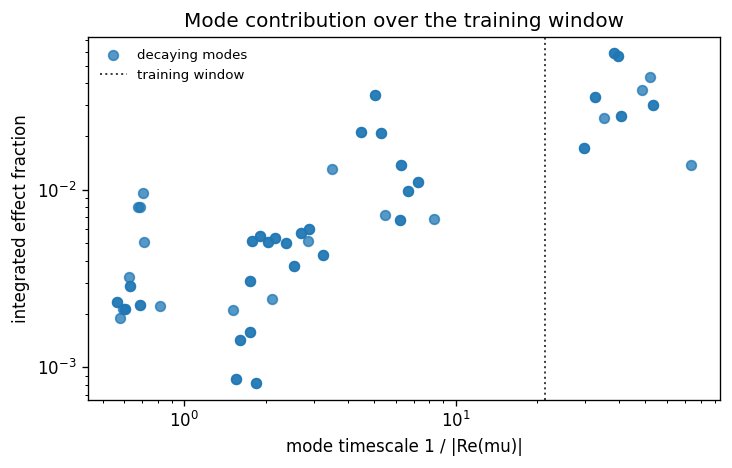

In [30]:
decay_mask = np.isfinite(mode_diag['tau'])
grow_mask = np.real(fit['mu']) > 1e-10
near_const_mask = (~decay_mask) & (~grow_mask)

fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.scatter(mode_diag['tau'][decay_mask], mode_diag['effect_fraction'][decay_mask],
           s=34, alpha=0.75, label='decaying modes')
if np.any(grow_mask):
    grow_x = np.full(np.sum(grow_mask), T_window)
    ax.scatter(grow_x, mode_diag['effect_fraction'][grow_mask], marker='x', s=42,
               color='tab:red', label='growing modes, shown at T_window')
if np.any(near_const_mask):
    const_x = np.full(np.sum(near_const_mask), T_window)
    ax.scatter(const_x, mode_diag['effect_fraction'][near_const_mask], marker='D', s=26,
               color='0.35', label='near-constant modes, shown at T_window')

ax.axvline(T_window, color='0.25', ls=':', lw=1.2, label='training window')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('mode timescale 1 / |Re(mu)|')
ax.set_ylabel('integrated effect fraction')
ax.set_title('Mode contribution over the training window')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()


In [31]:
def reconstruct_dmd(fit, psi0, times):
    """Reconstruct feature trajectory from one initial dictionary vector."""
    Phi = fit['Phi']
    mu = fit['mu']
    b = np.linalg.lstsq(Phi, psi0, rcond=None)[0]
    dynamics = np.exp(np.outer(mu, times)) * b[:, None]
    return (Phi @ dynamics).T

Psi_hats = np.stack([
    reconstruct_dmd(fit, Psis[j, 0], times)
    for j in range(n_configs)
], axis=0)

sigma = np.sqrt(c_eq * (1.0 - c_eq))
mean_hats = np.real(Psi_hats[:, :, 1:] * sigma + c_eq)
rel_errs = np.linalg.norm(mean_hats - mean_trajs, axis=(1, 2)) / np.linalg.norm(mean_trajs - c_eq, axis=(1, 2))
print(f'relative reconstruction error, mean +/- sd: {rel_errs.mean():.3e} +/- {rel_errs.std():.3e}')
for j, err in enumerate(rel_errs):
    print(f'  config {j + 1:2d}: {err:.3e}')


relative reconstruction error, mean +/- sd: 9.704e-02 +/- 2.251e-03
  config  1: 9.950e-02
  config  2: 9.477e-02
  config  3: 9.552e-02
  config  4: 9.741e-02
  config  5: 9.558e-02
  config  6: 9.903e-02
  config  7: 1.031e-01
  config  8: 9.460e-02
  config  9: 9.816e-02
  config 10: 9.753e-02
  config 11: 9.589e-02
  config 12: 9.793e-02
  config 13: 9.368e-02
  config 14: 9.637e-02
  config 15: 9.550e-02
  config 16: 9.800e-02


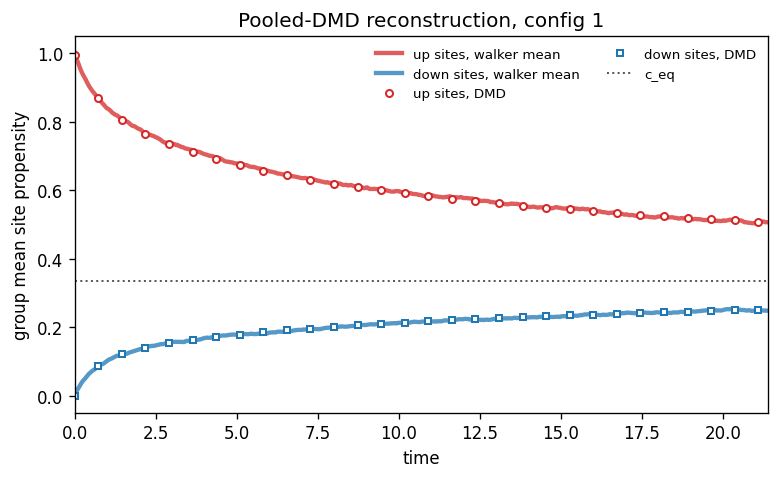

In [32]:
plot_config = 0
state_plot = state_inits[plot_config]
up_mask = state_plot == 1
dn_mask = state_plot == 0

mean_traj_plot = mean_trajs[plot_config]
mean_hat_plot = mean_hats[plot_config]

mean_up = mean_traj_plot[:, up_mask].mean(axis=1)
mean_dn = mean_traj_plot[:, dn_mask].mean(axis=1)
mean_up_hat = mean_hat_plot[:, up_mask].mean(axis=1)
mean_dn_hat = mean_hat_plot[:, dn_mask].mean(axis=1)
marker_stride = max(1, len(times) // 28)

fig, ax = plt.subplots(figsize=(6.6, 4.1))
ax.plot(times, mean_up, color='tab:red', lw=2.6, alpha=0.75,
        label='up sites, walker mean')
ax.plot(times, mean_dn, color='tab:blue', lw=2.6, alpha=0.75,
        label='down sites, walker mean')
ax.plot(times, mean_up_hat, color='tab:red', marker='o', ls='None', ms=4.2,
        mfc='white', mec='tab:red', mew=1.2, markevery=marker_stride,
        label='up sites, DMD')
ax.plot(times, mean_dn_hat, color='tab:blue', marker='s', ls='None', ms=4.0,
        mfc='white', mec='tab:blue', mew=1.2, markevery=marker_stride,
        label='down sites, DMD')
ax.axhline(c_eq, color='0.35', ls=':', lw=1.2, label='c_eq')

ax.set_title(f'Pooled-DMD reconstruction, config {plot_config + 1}')
ax.set_xlabel('time')
ax.set_ylabel('group mean site propensity')
ax.margins(x=0)
ax.legend(frameon=False, ncol=2, fontsize=8)
fig.tight_layout()


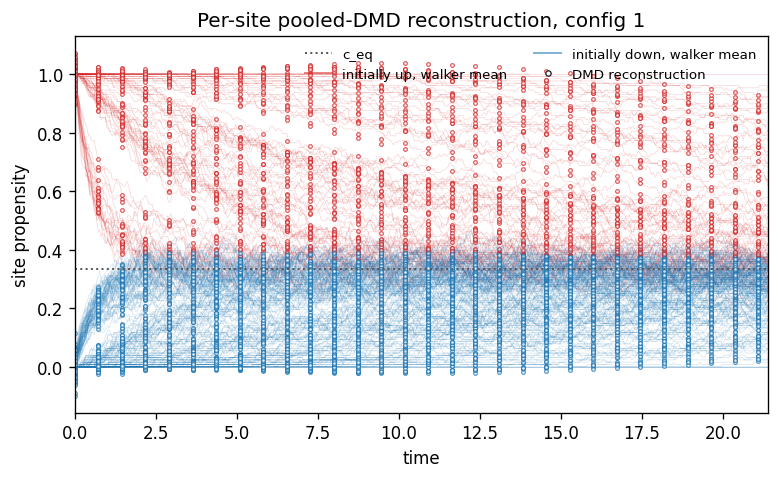

In [33]:
plot_config = 0
state_plot = state_inits[plot_config]
up_mask = state_plot == 1
dn_mask = state_plot == 0

mean_traj_plot = mean_trajs[plot_config]
mean_hat_plot = mean_hats[plot_config]
marker_stride = max(1, len(times) // 28)

fig, ax = plt.subplots(figsize=(6.6, 4.1))
for idx in np.where(up_mask)[0]:
    ax.plot(times, mean_traj_plot[:, idx], color='tab:red', lw=0.45, alpha=0.18)
    ax.plot(times, mean_hat_plot[:, idx], color='tab:red', marker='o', ls='None', ms=2.2,
            mfc='white', mec='tab:red', mew=0.75, alpha=0.75, markevery=marker_stride)
for idx in np.where(dn_mask)[0]:
    ax.plot(times, mean_traj_plot[:, idx], color='tab:blue', lw=0.45, alpha=0.18)
    ax.plot(times, mean_hat_plot[:, idx], color='tab:blue', marker='o', ls='None', ms=2.2,
            mfc='white', mec='tab:blue', mew=0.75, alpha=0.75, markevery=marker_stride)

ax.axhline(c_eq, color='0.35', ls=':', lw=1.2, label='c_eq')

# Proxy artists keep the legend readable without labeling every site.
ax.plot([], [], color='tab:red', lw=1.2, alpha=0.55, label='initially up, walker mean')
ax.plot([], [], color='tab:blue', lw=1.2, alpha=0.55, label='initially down, walker mean')
ax.plot([], [], color='0.15', marker='o', ls='None', ms=3.2,
        mfc='white', mec='0.15', mew=0.8, label='DMD reconstruction')

ax.set_title(f'Per-site pooled-DMD reconstruction, config {plot_config + 1}')
ax.set_xlabel('time')
ax.set_ylabel('site propensity')
ax.margins(x=0)
ax.legend(frameon=False, ncol=2, fontsize=8)
fig.tight_layout()


pseudospectrum grid computed in 199.4s


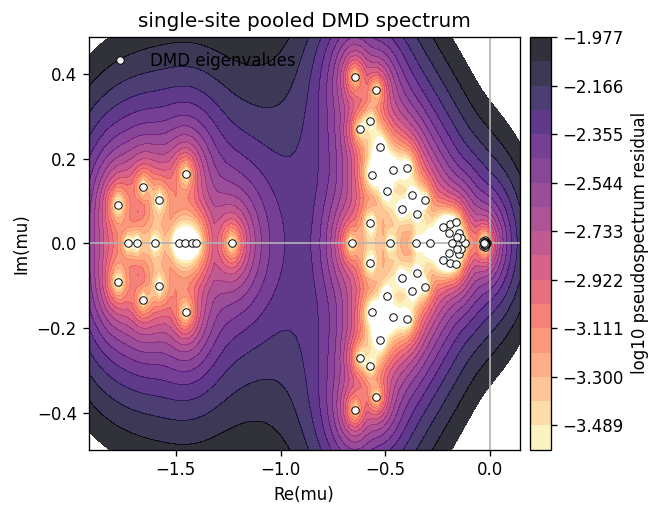

In [34]:
def dmd_pseudospectrum_mu(fit, dt, n_real=80, n_imag=60, real_pad=0.08, imag_pad=0.12):
    """Finite-dimensional DMD pseudospectrum in the continuous-time mu plane."""
    A = fit['A_tilde']
    mu = fit['mu']
    real = np.real(mu[np.isfinite(mu)])
    imag = np.imag(mu[np.isfinite(mu)])

    re_span = max(real.max() - real.min(), 1e-6)
    im_span = max(imag.max() - imag.min(), 1e-6)
    re_grid = np.linspace(real.min() - real_pad * re_span,
                          max(0.0, real.max()) + real_pad * re_span,
                          n_real)
    im_grid = np.linspace(imag.min() - imag_pad * im_span,
                          imag.max() + imag_pad * im_span,
                          n_imag)

    eye = np.eye(A.shape[0], dtype=complex)
    sigma_min = np.empty((n_imag, n_real), dtype=float)
    for j, im in enumerate(im_grid):
        for i, re in enumerate(re_grid):
            z = np.exp((re + 1j * im) * dt)
            sigma_min[j, i] = np.linalg.svd(z * eye - A, compute_uv=False)[-1]

    return re_grid, im_grid, np.log10(np.maximum(sigma_min, 1e-16))

plot_pseudospectrum = True

fig, ax = plt.subplots(figsize=(5.6, 4.4))
mu = fit['mu']

if plot_pseudospectrum:
    t0 = time.time()
    re_grid, im_grid, log_sigma_min = dmd_pseudospectrum_mu(fit, dt_record)
    levels = np.linspace(np.nanpercentile(log_sigma_min, 5),
                         np.nanpercentile(log_sigma_min, 95), 18)
    cf = ax.contourf(re_grid, im_grid, log_sigma_min, levels=levels,
                     cmap='magma_r', alpha=0.82)
    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label('log10 pseudospectrum residual')
    print(f'pseudospectrum grid computed in {time.time() - t0:.1f}s')

ax.axvline(0, color='0.7', lw=1)
ax.axhline(0, color='0.7', lw=1)
ax.plot(np.real(mu), np.imag(mu), 'o', ms=4.5, color='white', mec='black', mew=0.6,
        alpha=0.95, label='DMD eigenvalues')
ax.set_xlabel('Re(mu)')
ax.set_ylabel('Im(mu)')
ax.set_title('single-site pooled DMD spectrum')
ax.legend(frameon=False, loc='best')
fig.tight_layout()


## Next extension

Once this pooled single-site smoke test behaves sensibly, the next step is to replace `single_site_dictionary` with the downward-closed local cluster dictionary from `AGENTS.md`: evaluate products on each walker trajectory first, average those products over walkers, then apply the exact equilibrium centering/scaling for each cluster order.
